<style>
.jp-Notebook, .jp-Cell, body.jp-Notebook, .cell, div#notebook, .notebook {
  background-color: #0f1115 !important;
}
.jp-RenderedMarkdown, .rendered_html, .jp-RenderedHTMLCommon {
  color: #e6e6e6 !important; font-size: 16px; line-height: 1.6;
}
.jp-RenderedMarkdown h1, .jp-RenderedMarkdown h2, .jp-RenderedMarkdown h3,
.rendered_html h1, .rendered_html h2, .rendered_html h3 { color: #8ec7ff !important; }
.jp-RenderedMarkdown h1, .rendered_html h1 {
  border-bottom: 2px solid #2b4a6f; padding-bottom: .2em;
}
.jp-RenderedMarkdown a, .rendered_html a { color: #7fd1c1 !important; }
.jp-RenderedMarkdown code, .rendered_html code {
  background: #1b2430 !important; color: #ffd479 !important;
  padding: 1px 5px; border-radius: 4px;
}
.jp-RenderedMarkdown pre, .rendered_html pre {
  background: #1b2430 !important; color: #e6e6e6 !important;
  border-left: 3px solid #2b4a6f; padding: .6em .9em; border-radius: 6px;
}
.jp-RenderedMarkdown blockquote, .rendered_html blockquote {
  border-left: 4px solid #7fd1c1; color: #bcd; background: #141a22;
  padding: .3em 1em; border-radius: 0 6px 6px 0;
}
.jp-RenderedMarkdown table, .rendered_html table { color: #e6e6e6; }
.jp-RenderedMarkdown th, .rendered_html th { background: #1b2430 !important; }
</style>


# NB16 · Pendientes: hacia dónde sube el terreno

**Parte 2 · Matemáticas y herramientas para robots — Lección 5**

> En el **NB15** te enfrentaste al humanoide de verdad con tu política lineal, y te diste de bruces con el muro:
> **5.933 ruedecillas**, y probar al azar no sirve ni para igualar a no hacer nada. Necesitamos una forma de girar
> las ruedecillas **con cabeza**.

¿Recuerdas la **montaña con niebla** del NB04? Buscas la cumbre, pero no ves nada a dos metros. ¿Qué haces? No te
teletransportas a puntos al azar (eso es la búsqueda aleatoria). Haces algo mucho más listo: **notas con los pies hacia
dónde sube el suelo**, y das un paso hacia allí. Y otro. Y otro.

Esa sensación en los pies tiene un nombre en matemáticas: la **pendiente**. Los matemáticos la llaman **derivada**, y es
una de las ideas más poderosas que ha inventado la humanidad: con ella se calculan las órbitas de los planetas, se diseñan
puentes... y se entrenan **todas** las inteligencias artificiales que existen.

Suena a matemáticas "de mayores", pero vamos a construirla **desde cero**, con rampas, coches y dibujos, y la calcularemos
con el ordenador usando solo restas y divisiones. Al final, mediremos las pendientes de la "montaña" del palo de escoba y
sabremos, para cada ruedecilla, **hacia dónde girarla**.


## 1 · Una función: una máquina que convierte un número en otro

Antes de hablar de pendientes necesitamos una idea de matemáticas que, en realidad, ya conoces de Python.

Una **función matemática** es una regla que, a cada número que le das, le hace corresponder **otro número**. Como una
máquina con una ranura de entrada y otra de salida. Ejemplos:

- "Elevar al cuadrado": le das 3, te devuelve 9. Le das −2, te devuelve 4.
- "El retorno del palo de escoba según dónde pongas la ruedecilla de inclinación": le das 12, te devuelve unos puntos; le
  das 30, otros.
- "Dónde está un coche según el tiempo que ha pasado": le das 2 segundos, te devuelve 40 metros.

Los matemáticos las escriben con una letra, normalmente **f**, y el número de entrada entre paréntesis: **f(x)** ("efe de
equis"). Por ejemplo, "elevar al cuadrado" se escribe **f(x) = x²**, y entonces f(3) = 9.

¿Te suena? ¡Es una **función de Python** (NB10) que recibe un número y devuelve otro!


In [1]:
def f(x):
    return x ** 2

print(f(3), f(-2), f(0.5))

9 4 0.25


9, 4 y 0,25. La función matemática y la función de Python son la misma idea: entra un número, sale otro.


## 2 · La gráfica: el dibujo de una función

Una función se entiende mucho mejor **dibujada**. La idea: para muchos valores de entrada x, calculamos la salida f(x), y
ponemos un puntito en el plano (NB12) en la posición (x, f(x)). Al unir todos los puntitos, sale una línea: la **gráfica** de
la función.

Vamos a dibujar f(x) = x² entre −3 y 3. Fabricamos una lista de valores de x (de −3 a 3 en saltos de 0,1) y la lista de sus
salidas, con un bucle:


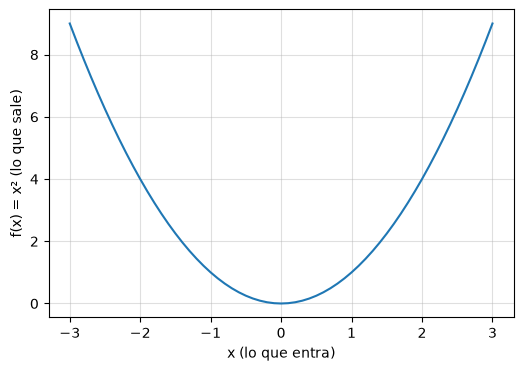

In [2]:
import matplotlib.pyplot as plt

xs = []
ys = []
for i in range(-30, 31):          # i va de -30 a 30...
    x = i / 10                    # ...así que x va de -3.0 a 3.0, en saltos de 0.1
    xs.append(x)
    ys.append(f(x))

plt.figure(figsize=(6, 4))
plt.plot(xs, ys, color="tab:blue")
plt.grid(True, alpha=0.4)
plt.xlabel("x (lo que entra)")
plt.ylabel("f(x) = x² (lo que sale)")
plt.show()

Una curva con forma de **U** (los matemáticos la llaman **parábola**). Léela así: cada punto de la curva dice "si entra
este x (abajo), sale este f(x) (a la izquierda)". En x = 0, la salida es 0 (el fondo de la U); en x = 3, es 9 (arriba a la
derecha). (`plt.xlabel` y `plt.ylabel` solo ponen el nombre de cada eje.)

Fíjate en cómo es la curva en distintos sitios:

- A la **derecha** de 0, la curva **sube**, y cada vez más empinada.
- A la **izquierda** de 0, la curva **baja** (yendo de izquierda a derecha).
- Justo en el **0**, en el fondo, está **plana**.

Ese "cuánto sube o baja, y cómo de empinada" es la **pendiente**. Vamos a darle números.


## 3 · La pendiente de una rampa

Empecemos por lo más sencillo: una **rampa recta**, como la de un garaje o la de una pista de patinaje.

¿Has visto alguna vez una señal de tráfico con un **10 %** y un dibujo de una cuesta? Significa: "**por cada 100 metros que
avanzas, subes (o bajas) 10**". Eso es una pendiente:

```
   pendiente = lo que SUBE  ÷  lo que AVANZA
```

```
                                        ●
                                     ╱  │
                                  ╱     │  sube 3
                               ╱        │
                            ●───────────┘
                               avanza 6

          pendiente = 3 ÷ 6 = 0,5      (por cada paso adelante, sube medio)
```

Tres casos, que ya viste en la parábola:

| Rampa | Pendiente | Ejemplo |
|---|---|---|
| Sube (yendo hacia la derecha) | **positiva** | sube 3, avanza 6 → +0,5 |
| Baja | **negativa** | baja 3 (sube −3), avanza 6 → −0,5 |
| Plana | **cero** | sube 0, avanza 6 → 0 |

Y cuanto **más grande** es el número (sin mirar el signo), **más empinada** es la rampa. Una pendiente de 2 es mucho más
empinada que una de 0,1.

Lo importante: en una rampa **recta**, la pendiente es **la misma en todas partes**. Da igual dónde la midas.


## 4 · Ya conoces una pendiente: la velocidad

Aquí viene una conexión preciosa con el NB02. Imagina una gráfica donde, en vez de "x" y "f(x)", pones el **tiempo** (abajo) y
la **posición** de un coche (a la izquierda). Si el coche va a velocidad constante, por ejemplo a 20 metros por segundo:

| Tiempo (s) | 0 | 1 | 2 | 3 |
|---|---|---|---|---|
| Posición (m) | 0 | 20 | 40 | 60 |

La gráfica es una rampa recta. ¿Su pendiente? Por cada segundo que "avanza" el tiempo, la posición "sube" 20 metros:
**pendiente = 20 ÷ 1 = 20**... ¡que es exactamente su **velocidad**, 20 m/s!

> **La velocidad es la pendiente de la posición.** Dice cuánto cambia la posición por cada segundo.

Y del mismo modo, la **aceleración** es la pendiente de la **velocidad** (cuánto cambia la velocidad por cada segundo). ¿Te
suena? Es la **cadena de oro** del NB02, dicha con pendientes:

```
   fuerza ──► cambia la velocidad (aceleración = pendiente de la velocidad)
   velocidad ──► cambia la posición (velocidad = pendiente de la posición)
```

El simulador del NB07, con sus pasitos, estaba usando pendientes sin decirlo: "si la velocidad (la pendiente) es tanta, en este
pasito la posición cambia tanto". Llevas desde el NB06 trabajando con derivadas. Solo que no lo sabías.


## 5 · ¿Y la pendiente de una curva?

En una rampa recta, la pendiente es la misma en todas partes. Pero en una **curva**, como la parábola, la pendiente **cambia** de
un sitio a otro: cerca del fondo es suave, y más arriba es empinadísima. Así que la pregunta correcta no es "¿cuál es la pendiente
de la parábola?", sino "**¿cuál es la pendiente de la parábola EN tal punto?**".

¿Y cómo se mide la pendiente en un punto de una curva? Con un truco genial, que es la idea clave de toda esta lección:

> **Si miras una curva muy, muy de cerca, parece una recta.**

Piénsalo: la Tierra es una bola, pero a tu alrededor el suelo parece plano. Es tan grande, y tú la miras tan de cerca, que su
curvatura no se nota. Con cualquier curva pasa lo mismo: si haces suficiente **zoom** en un punto, el trocito que ves es
prácticamente una rampa recta. Y la pendiente de esa rampa es la pendiente de la curva **en ese punto**.

Comprobémoslo haciendo zoom en la parábola alrededor de x = 3. Dibujamos la curva cada vez más de cerca: de 2 a 4, de 2,9 a 3,1, y
de 2,99 a 3,01. Para no repetir código, una función que dibuja la parábola entre dos valores (usando `plt.subplot` para poner tres
dibujos en fila; es un detalle de dibujo, no hace falta memorizarlo):


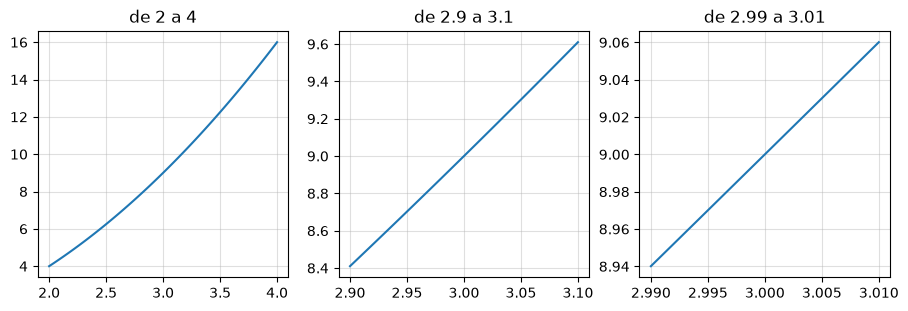

In [3]:
def dibujar_trozo(desde, hasta, posicion):
    xs = []
    ys = []
    for i in range(101):
        x = desde + (hasta - desde) * i / 100     # 101 puntos repartidos entre 'desde' y 'hasta'
        xs.append(x)
        ys.append(f(x))
    plt.subplot(1, 3, posicion)                   # dibujo número 'posicion' de una fila de 3
    plt.plot(xs, ys, color="tab:blue")
    plt.title("de " + str(desde) + " a " + str(hasta))
    plt.grid(True, alpha=0.4)

plt.figure(figsize=(11, 3.2))
dibujar_trozo(2, 4, 1)
dibujar_trozo(2.9, 3.1, 2)
dibujar_trozo(2.99, 3.01, 3)
plt.show()

(El `str(...)` convierte un número en texto para poder pegarlo a otro texto con `+`, y así escribir el título.)

En el primer dibujo se ve claramente la curva. En el segundo, ya casi es recta. En el tercero, **es una recta** a todos los efectos.
Ese trocito de recta tiene una pendiente concreta... y esa es **la pendiente de la parábola en x = 3**.


## 6 · Calcular la pendiente con números

Ahora vamos a **calcular** esa pendiente, con la definición de la rampa ("lo que sube ÷ lo que avanza") aplicada a un trocito muy
pequeño de la curva.

La receta: estando en x = 3, **avanza un poquito**, una cantidad pequeña que llamaremos **h**. Mira cuánto ha **subido** la función,
y divide entre lo que has avanzado:

```
                    f(x + h) − f(x)          lo que sube
   pendiente  ≈  ─────────────────────  =  ──────────────
                           h                lo que avanza
```

Probemos con un h no muy pequeño, h = 1: avanzar de 3 a 4. La función sube de f(3) = 9 a f(4) = 16, o sea 7. Pendiente ≈ 7 ÷ 1 = 7.
Pero eso es la pendiente de la rampa entre 3 y 4, y la curva se va empinando por el camino. Hay que hacer **h más pequeño**, para
mirar más de cerca (el zoom). Vamos con una función de Python que lo calcula, y una tabla con h cada vez más pequeño:


In [4]:
def pendiente_aprox(funcion, x, h):
    return (funcion(x + h) - funcion(x)) / h

for h in [1, 0.1, 0.01, 0.001]:
    print("h =", h, "-> pendiente ≈", pendiente_aprox(f, 3, h))

h = 1 -> pendiente ≈ 7.0
h = 0.1 -> pendiente ≈ 6.100000000000012
h = 0.01 -> pendiente ≈ 6.009999999999849
h = 0.001 -> pendiente ≈ 6.000999999999479


(Fíjate: a `pendiente_aprox` le pasamos **la función `f` entera** como argumento, igual que pasábamos la política en el NB10.)

Mira cómo se van acercando: **7 → 6,1 → 6,01 → 6,001**. Cada vez que h se hace 10 veces más pequeño, nos acercamos 10 veces más a...
**6**. La pendiente de la parábola en x = 3 es **6**.

Ese número al que se acercan las aproximaciones cuando h se hace pequeñísimo tiene nombre: es la **derivada** de f en x = 3. **Una
derivada es la pendiente de una curva en un punto**, calculada mirando un trocito infinitamente pequeño. (Los matemáticos tienen
formas de calcularla exacta sin hacer tablas; para nosotros, con el ordenador, la aproximación con un h pequeño es más que suficiente.)


### Un truco mejor: mirar a los dos lados

Hay una forma más precisa, casi igual de fácil: en vez de avanzar solo hacia la derecha, avanzar un poquito **hacia los dos lados** y
medir la rampa entre esos dos puntos (que están separados por 2h):

```
                    f(x + h) − f(x − h)
   pendiente  ≈  ───────────────────────
                           2h
```

Es como medir la cuesta poniendo un pie un poco por delante y otro un poco por detrás, en vez de los dos por delante. Comparémoslo:


In [5]:
def pendiente(funcion, x, h):
    return (funcion(x + h) - funcion(x - h)) / (2 * h)

for h in [1, 0.1, 0.01]:
    print("h =", h, "-> pendiente ≈", pendiente(funcion=f, x=3, h=h))

h = 1 -> pendiente ≈ 6.0
h = 0.1 -> pendiente ≈ 6.000000000000005
h = 0.01 -> pendiente ≈ 5.999999999999872


¡**6** desde el principio (con su ruidito de decimales del NB06)! Mirando a los dos lados, los errores de un lado y del otro se
compensan. A partir de ahora usaremos esta versión, que llamaremos simplemente `pendiente`.

(Una novedad pequeña: hemos escrito `pendiente(funcion=f, x=3, h=h)`, poniendo **el nombre de cada parámetro** delante de su valor.
Python lo permite, y a veces aclara mucho qué es cada cosa. Es lo mismo que `pendiente(f, 3, h)`.)


### El límite del ordenador: tampoco tan pequeño

¿Entonces cuanto más pequeño sea h, mejor? Casi. Comparemos un h muy pequeño, 10⁻⁶ (una millonésima, `1e-6` en notación
científica, NB14), con uno **ridículamente** pequeño, 10⁻¹² (una billonésima):


In [6]:
print("h = 1e-6: ", pendiente_aprox(f, 3, 1e-6))
print("h = 1e-12:", pendiente_aprox(f, 3, 1e-12))

h = 1e-6:  6.000001000927568
h = 1e-12: 6.000533403494046


Con h = 10⁻⁶ sale 6,000001: casi perfecto. Pero con h = 10⁻¹², ¡la aproximación **empeora** (6,0005, unas 500 veces más lejos
de 6)! Haciendo h un millón de veces más pequeño, hemos ido a peor. ¿Por qué? Por nuestro viejo amigo, el **ruido de los decimales** (NB06). Con un
h tan pequeñísimo, f(3 + h) y f(3) son casi idénticos, y al restarlos, el resultado es tan diminuto que el pequeño error de cada
decimal se vuelve **enorme** en proporción. Es como intentar medir el grosor de un pelo con una regla de un metro.

Lección práctica: **h pequeño, pero no absurdamente pequeño**. Algo como 0,001 suele ir bien. Los matemáticos pueden hacer h
"infinitamente pequeño" en papel; el ordenador, no.


## 7 · La pendiente también es una función

Calculemos la pendiente de la parábola en **varios** puntos, no solo en 3:

In [7]:
for x in [-2, -1, 0, 1, 2, 3]:
    print("en x =", x, "-> pendiente ≈", round(pendiente(f, x, 0.001), 3))

en x = -2 -> pendiente ≈ -4.0
en x = -1 -> pendiente ≈ -2.0
en x = 0 -> pendiente ≈ 0.0
en x = 1 -> pendiente ≈ 2.0
en x = 2 -> pendiente ≈ 4.0
en x = 3 -> pendiente ≈ 6.0


Mira la tabla con atención:

| x | −2 | −1 | 0 | 1 | 2 | 3 |
|---|---|---|---|---|---|---|
| pendiente | −4 | −2 | 0 | 2 | 4 | 6 |

1. **A la izquierda del 0**, la pendiente es **negativa**: la curva baja. **A la derecha**, **positiva**: sube. **En el 0**, **cero**:
   el fondo plano de la U. ¡Justo lo que vimos en la gráfica!
2. Y hay un patrón: la pendiente es siempre **el doble de x**. En x = 3, 6; en x = −2, −4. La pendiente de x² en cualquier punto es
   **2x**.

Es decir: la pendiente **también es una función**: le das un x, y te devuelve la pendiente de la curva en ese punto. Por eso los
matemáticos dicen "**la derivada de x² es 2x**". Acabas de descubrir tu primera derivada... con una tabla.


## 8 · Leer la pendiente para subir

Y ahora, la razón por la que estamos aquí. Vuelve a la montaña con niebla. Si estás en un punto y conoces la **pendiente** del terreno
bajo tus pies:

```
   pendiente POSITIVA  →  el terreno sube hacia la derecha   →  para subir, ve a la DERECHA (aumenta x)
   pendiente NEGATIVA  →  el terreno sube hacia la izquierda →  para subir, ve a la IZQUIERDA (disminuye x)
   pendiente CERO      →  estás en un sitio plano: ¿la cumbre? (o un valle, o una meseta)
```

Y el **tamaño** de la pendiente también dice algo: si es grande, el terreno es muy empinado y aún estás **lejos** de la cumbre; si es
pequeña, el terreno se está aplanando y estás **cerca**.

Fíjate en la maravilla: **con un solo número** (la pendiente), sabes **hacia dónde ir** y **cuánto te falta**, sin ver nada de la
montaña. Para un robot con una ruedecilla, eso significa: "**si la pendiente del retorno es positiva, aumenta la ruedecilla; si es
negativa, disminúyela**". Vamos a comprobarlo con un robot de verdad.


## 9 · La montaña del palo de escoba

Volvamos al proyecto del NB11. Para que la montaña sea interesante, añadimos el detalle del ejercicio E7 de aquel notebook: **el motor
gasta batería**. Cada paso, la recompensa pierde un poquito según lo fuerte que empuje el motor (0,001 × empuje²). Así, empujar a lo
loco ya no sale gratis, y aparece un **equilibrio**: si la ruedecilla es demasiado pequeña, el palo se cae; si es demasiado grande, el
motor derrocha batería. En algún punto intermedio estará la **cumbre**.

Esta celda es **el mundo del NB11, copiado**, con ese único cambio, y con la ruedecilla de velocidad fija en 8. La función
`retorno(ruedecilla)` nos da el retorno medio de 5 episodios según dónde pongamos la ruedecilla de **inclinación**. Es decir: es una
**función matemática** (entra un número, sale otro), aunque por dentro tenga un simulador entero:


In [8]:
import random

def retorno(ruedecilla_inclinacion):
    ruedecilla_velocidad = 8
    total = 0
    for semilla in range(5):
        random.seed(semilla)
        inclinacion = 2.0
        velocidad = 0.0
        for n in range(500):
            empuje = -ruedecilla_inclinacion * inclinacion - ruedecilla_velocidad * velocidad   # la política
            if empuje > 40:
                empuje = 40
            if empuje < -40:
                empuje = -40
            aceleracion = 10 * inclinacion + empuje + random.uniform(-30, 30)             # la física
            velocidad = velocidad + aceleracion * 0.02
            inclinacion = inclinacion + velocidad * 0.02
            if inclinacion > 30 or inclinacion < -30:                                     # ¿se cayó?
                break
            total = total + 1 - (inclinacion / 30) ** 2 - 0.001 * empuje ** 2             # recompensa con batería
    return total / 5

print("Retorno con la ruedecilla en 30:", round(retorno(30), 1))

Retorno con la ruedecilla en 30: 460.2


Con la ruedecilla en 30 (la de la política a mano del NB11), unos **460 puntos** (algo menos que los 499,9 de entonces, porque ahora
empujar cuesta batería). Ahora, **dibujemos la montaña**: el retorno para la ruedecilla entre 8 y 60:


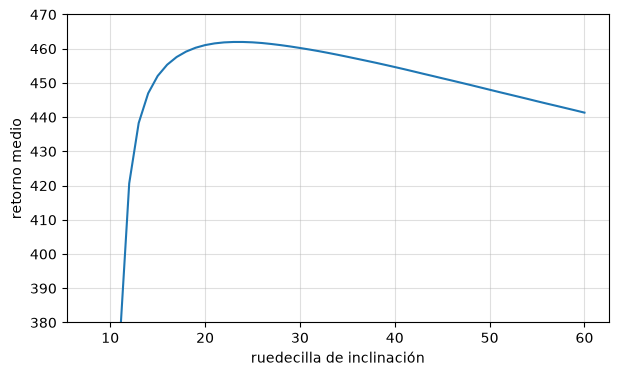

In [9]:
ruedecillas = []
retornos = []
for r in range(8, 61):
    ruedecillas.append(r)
    retornos.append(retorno(r))

plt.figure(figsize=(7, 4))
plt.plot(ruedecillas, retornos, color="tab:blue")
plt.grid(True, alpha=0.4)
plt.xlabel("ruedecilla de inclinación")
plt.ylabel("retorno medio")
plt.ylim(380, 470)                 # para ver bien la cumbre (corta el principio, que cae muy abajo)
plt.show()

¡Ahí está la montaña! (Hemos cortado el dibujo por abajo para ver bien la parte alta: con la ruedecilla en 8, el retorno es −38,
muy abajo, porque el palo se cae y además el motor gasta batería.)

- Desde la izquierda, el retorno **sube** rapidísimo: más ruedecilla = el palo deja de caerse.
- Hay una **cumbre** suave, hacia la mitad de los 20.
- Y a la derecha, **baja** poco a poco: más ruedecilla = más empujones = más batería gastada, sin ganar estabilidad.

Ahora, la prueba de fuego: midamos la **pendiente** en tres sitios, con nuestra función `pendiente` (con h = 0,5: el retorno no es
una curva tan "fina" como la parábola, y un h razonable va mejor):


In [10]:
for r in [12, 23.5, 40]:
    print("ruedecilla", r, "| retorno", round(retorno(r), 1), "| pendiente", round(pendiente(retorno, r, 0.5), 3))

ruedecilla 12 | retorno 420.6 | pendiente 27.535
ruedecilla 23.5 | retorno 462.0 | pendiente -0.001
ruedecilla 40 | retorno 454.6 | pendiente -0.633


Léelo como un montañero con niebla:

| Ruedecilla | Retorno | Pendiente | Lo que dicen tus pies |
|---|---|---|---|
| 12 | 420,6 | **+27,5** | "¡Sube muchísimo hacia la derecha!" → aumenta la ruedecilla, y mucho |
| 23,5 | 462,0 | **≈ 0** | "Esto está plano" → estás en la **cumbre** |
| 40 | 454,6 | **−0,63** | "Sube un poco hacia la izquierda" → disminuye la ruedecilla, un poco |

**La pendiente sabe hacia dónde está la cumbre, sin ver la montaña.** Desde 12, dice "a la derecha, y estás lejos" (pendiente grande);
desde 40, "a la izquierda, y estás cerca" (pendiente pequeña); y en 23,5, "ya has llegado" (cero).

Y fíjate en lo barato que es: para saber hacia dónde ir, solo hemos necesitado evaluar el retorno **dos veces** (un poco a la izquierda
y un poco a la derecha). Nada de probar cientos de valores al azar.


## 10 · Resumen de la lección

1. Una **función matemática** f(x) convierte un número en otro (como una función de Python), y su **gráfica** es el dibujo de todos sus
   puntos (x, f(x)).
2. La **pendiente** de una rampa es **lo que sube ÷ lo que avanza**: positiva si sube, negativa si baja, cero si es plana. La
   **velocidad** es la pendiente de la posición, y la **aceleración**, la de la velocidad (la cadena de oro del NB02).
3. Una curva vista muy de cerca parece una recta: su **pendiente en un punto** (la **derivada**) se calcula con (f(x + h) − f(x)) / h
   para un **h** pequeño, o mejor, **mirando a los dos lados**: (f(x + h) − f(x − h)) / 2h. Pero no con un h absurdamente pequeño (ruido
   de decimales).
4. La pendiente también es una función: la de x² es **2x** (descubierto con una tabla).
5. El **signo** de la pendiente dice **hacia dónde subir** y su **tamaño**, **cuánto falta**. En la montaña del palo de escoba con
   batería: +27,5 en 12, ≈ 0 en 23,5 (la cumbre, ~462 puntos), −0,63 en 40.

### Palabras nuevas de hoy

| Palabra | Qué significa |
|---|---|
| **Función matemática f(x)** | Regla que convierte cada número de entrada en uno de salida. |
| **Gráfica** | El dibujo de una función: todos sus puntos (x, f(x)). |
| **Parábola** | La curva en forma de U de f(x) = x². |
| **Pendiente** | Lo que sube ÷ lo que avanza: cómo de empinada es una rampa o una curva. |
| **Derivada** | La pendiente de una curva en un punto. |
| **h** | El "poquito" que se avanza para medir una pendiente con números. |
| **Diferencia a los dos lados** | (f(x + h) − f(x − h)) / 2h: la forma más precisa de medirla. |
| **Cumbre / máximo** | El punto más alto, donde la pendiente es cero. |
| **`str(...)`** | Convierte un número en texto. |


## 11 · Ejercicios

**E1.** Una rampa sube 2 metros por cada 8 que avanzas. ¿Cuál es su pendiente? ¿Y en porcentaje (como la señal de tráfico)?

**E2.** Un coche está en la posición 10 m en el segundo 2, y en la posición 70 m en el segundo 5. Si va a velocidad constante, ¿a qué
velocidad va? (Pista: velocidad = pendiente de la posición.)

**E3.** Calcula con `pendiente` la pendiente de f(x) = x² en x = 10 y en x = −5. ¿Cumple la regla del "doble de x"?

**E4.** Define la función g(x) = x³ (x al cubo, es decir, `x ** 3`) y calcula su pendiente en x = 1, 2 y 3. ¿Ves algún patrón? (Pista:
compara con 3 × x².)

**E5.** En la montaña del palo de escoba, ¿qué pendiente esperas en la ruedecilla 60, positiva o negativa? ¿Y en la 16? Piénsalo mirando
la gráfica y luego compruébalo.

**E6.** **Reto.** Escribe un bucle que recorra la ruedecilla de 8 a 60 y diga dónde está la cumbre **sin dibujar nada**: el valor de la
ruedecilla con el retorno más alto. (Pista: el patrón "guardar el mejor" del NB11.) ¿Cuántas veces has tenido que llamar a `retorno`? En
el NB17 encontraremos la cumbre con **muchas menos** llamadas.


<details>
<summary>▶ Solución E1</summary>

Pendiente = 2 ÷ 8 = **0,25**. En porcentaje: 0,25 × 100 = **25 %** (por cada 100 metros que avanzas, subes 25: ¡una cuesta durísima!
Las carreteras rara vez pasan del 10-15 %).
</details>

<details>
<summary>▶ Solución E2</summary>

Lo que "sube" la posición: 70 − 10 = 60 metros. Lo que "avanza" el tiempo: 5 − 2 = 3 segundos. Velocidad = 60 ÷ 3 = **20 m/s** (72 km/h).
</details>

<details>
<summary>▶ Solución E3</summary>

```python
print(round(pendiente(f, 10, 0.001), 3))
print(round(pendiente(f, -5, 0.001), 3))
```

Salen **20** y **−10**: el doble de 10 y el doble de −5. Sí, cumple la regla 2x.
</details>

<details>
<summary>▶ Solución E4</summary>

```python
def g(x):
    return x ** 3

for x in [1, 2, 3]:
    print(x, round(pendiente(g, x, 0.001), 3))
```

Salen aproximadamente **3, 12 y 27**. Y 3 × 1² = 3, 3 × 2² = 12, 3 × 3² = 27: la pendiente de x³ es **3x²**. (Los matemáticos tienen una
regla general: la derivada de x elevado a n es n × x elevado a n − 1. Para x², 2x; para x³, 3x². Acabas de comprobarla.)
</details>

<details>
<summary>▶ Solución E5</summary>

En **60**, la montaña baja hacia la derecha, así que la pendiente es **negativa** (pequeña, porque baja suave). En **16**, la montaña aún
sube hacia la derecha: **positiva**, y bastante (estamos en la ladera de subida).

```python
print(round(pendiente(retorno, 60, 0.5), 3))
print(round(pendiente(retorno, 16, 0.5), 3))
```
</details>

<details>
<summary>▶ Solución E6</summary>

```python
mejor_ruedecilla = None
mejor_retorno = -1000
for r in range(8, 61):
    valor = retorno(r)
    if valor > mejor_retorno:
        mejor_retorno = valor
        mejor_ruedecilla = r
print(mejor_ruedecilla, round(mejor_retorno, 1))
```

La cumbre sale en la ruedecilla **23 o 24** (con un retorno de ~462). Hemos llamado a `retorno` **53 veces** (una por cada valor de 8 a 60),
y solo hemos probado números enteros. (Empezamos con `mejor_retorno = -1000` porque, con batería, algunos retornos son negativos.) En el
NB17, siguiendo la pendiente, llegaremos a la cumbre con muchas menos llamadas... y funcionará también con **muchas ruedecillas a la vez**,
donde recorrer todas las combinaciones sería imposible.
</details>


## 12 · Posdata

Si algo no ha quedado claro, dime el **apartado** y la **frase exacta** y lo reescribo.

Hoy has aprendido a medir **hacia dónde sube el terreno**: la pendiente, o derivada. Has descubierto que la velocidad era una pendiente,
que la derivada de x² es 2x, y que la pendiente del retorno del palo de escoba **señala la cumbre** sin necesidad de ver la montaña.

En el **NB17** daremos el paso que convierte esto en **aprendizaje**: un bucle que, una y otra vez, mide la pendiente y **da un paso cuesta
arriba**. Se llama **ascenso por la pendiente** (o, cuando se baja en vez de subir, **descenso por gradiente**), y es el algoritmo con el que
se entrenan **todas** las redes neuronales del mundo. Lo usaremos para que el palo de escoba ajuste **sus dos ruedecillas a la vez**, y
veremos qué es una **"tasa de aprendizaje"** y qué pasa cuando es demasiado grande.
